# Aprendizaje No Supervisado - Clustering de Estaciones
## Actividad 4 - Inteligencia Artificial

**Integrantes:**
- Jose Andres de la Ossa Carmona

**Objetivo:** Agrupar estaciones por patrones de uso usando K-Means.


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

print("Librerías importadas correctamente")

Librerías importadas correctamente


In [3]:
# Cargar el dataset
datos = pd.read_csv('./sample_data/datos_clustering.csv')

print(f"Total de registros: {len(datos)}")
print(f"Columnas: {list(datos.columns)}")
print("\nPrimeras 10 filas:")
datos.head(10)

Total de registros: 124
Columnas: ['hora', 'dia_semana', 'estacion', 'clima', 'pasajeros_entrada', 'pasajeros_salida', 'duracion_promedio']

Primeras 10 filas:


,hora,dia_semana,estacion,clima,pasajeros_entrada,pasajeros_salida,duracion_promedio
0,7,1,Portal,soleado,450,120,5
1,7,1,San_Javier,soleado,380,95,4
2,7,2,Portal,lluvia,520,140,6
3,8,1,Floresta,soleado,310,85,4
4,8,2,Estadio,nublado,290,75,4
5,9,1,Aljaraque,soleado,150,180,3
6,9,2,Cisneros,lluvia,180,200,3
7,10,1,Parque_Berrio,soleado,120,250,3
8,10,2,Portal,nublado,140,230,3
9,11,1,San_Javier,soleado,100,200,3


In [4]:
# Codificar variables categóricas
le_estacion = LabelEncoder()
le_clima = LabelEncoder()

datos['estacion_cod'] = le_estacion.fit_transform(datos['estacion'])
datos['clima_cod'] = le_clima.fit_transform(datos['clima'])

# Seleccionar características numéricas para clustering
caracteristicas = ['hora', 'pasajeros_entrada', 'pasajeros_salida', 'duracion_promedio']
X = datos[caracteristicas]

print("Variables seleccionadas para clustering:")
print(caracteristicas)

Variables seleccionadas para clustering:
['hora', 'pasajeros_entrada', 'pasajeros_salida', 'duracion_promedio']


In [6]:
# Estandarizar datos (importante para K-Means)
scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

print("Datos estandarizados")
print(f"Media: {X_escalado.mean(axis=0)}")
print(f"Desviación: {X_escalado.std(axis=0)}")

Datos estandarizados
Media: [ 1.40568560e-16 -6.08831981e-17 -4.56623986e-17  2.07719147e-16]
Desviación: [1. 1. 1. 1.]


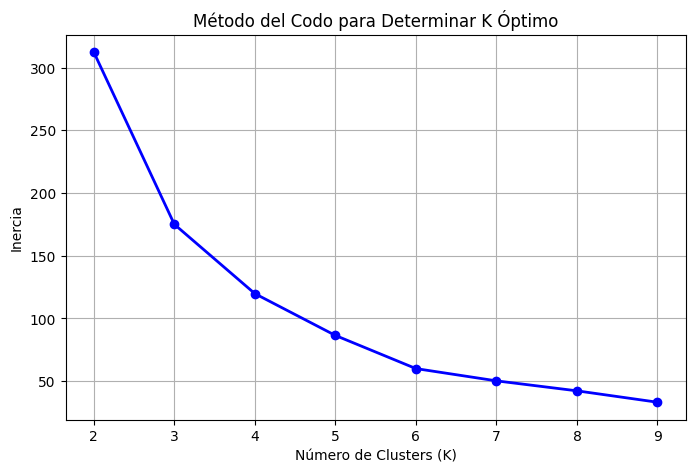

Observen el gráfico: El 'codo' indica el K óptimo


In [8]:
# Método del codo para determinar número óptimo de clusters
inercias = []
rango_k = range(2, 10)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_escalado)
    inercias.append(kmeans.inertia_)

# Gráfico del codo
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, 'bo-', linewidth=2)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo para Determinar K Óptimo')
plt.grid(True)
plt.show()

print("Observen el gráfico: El 'codo' indica el K óptimo")

In [9]:
# Entrenar K-Means con K óptimo (generalmente 3 o 4)
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
kmeans.fit(X_escalado)

# Agregar cluster al dataset
datos['cluster'] = kmeans.labels_

print(f"Modelo entrenado con {k_optimo} clusters")
print(f"Distribución de clusters:")
print(datos['cluster'].value_counts().sort_index())

Modelo entrenado con 3 clusters
Distribución de clusters:
cluster
0    20
1    69
2    35
Name: count, dtype: int64


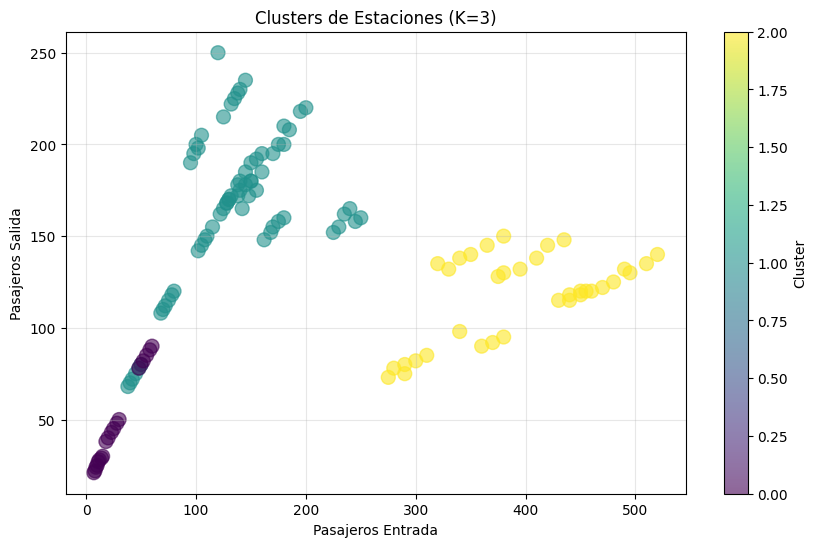

In [10]:
# Visualizar clusters (usando 2 variables para el gráfico 2D)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(datos['pasajeros_entrada'],
                      datos['pasajeros_salida'],
                      c=datos['cluster'],
                      cmap='viridis',
                      alpha=0.6,
                      s=100)

plt.xlabel('Pasajeros Entrada')
plt.ylabel('Pasajeros Salida')
plt.title(f'Clusters de Estaciones (K={k_optimo})')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [11]:
# Analizar características de cada cluster
print("\nCENTROS DE CLUSTERS (valores estandarizados):")
centros = pd.DataFrame(kmeans.cluster_centers_, columns=caracteristicas)
print(centros)

print("\nCARACTERÍSTICAS POR CLUSTER (valores originales):")
for i in range(k_optimo):
    cluster_data = datos[datos['cluster'] == i][caracteristicas]
    print(f"\n--- Cluster {i} ---")
    print(cluster_data.mean())


CENTROS DE CLUSTERS (valores estandarizados):
       hora  pasajeros_entrada  pasajeros_salida  duracion_promedio
0 -1.419066          -1.142801         -1.538622          -1.127189
1  0.385444          -0.387929          0.594443          -0.317198
2  0.051019           1.417803         -0.292688           1.269440

CARACTERÍSTICAS POR CLUSTER (valores originales):

--- Cluster 0 ---
hora                  4.70
pasajeros_entrada    27.65
pasajeros_salida     48.65
duracion_promedio     2.30
dtype: float64

--- Cluster 1 ---
hora                  15.449275
pasajeros_entrada    135.608696
pasajeros_salida     166.840580
duracion_promedio      3.144928
dtype: float64

--- Cluster 2 ---
hora                  13.457143
pasajeros_entrada    393.857143
pasajeros_salida     117.685714
duracion_promedio      4.800000
dtype: float64


In [15]:
# Interpretación de clusters
print("\nINTERPRETACIÓN DE CLUSTERS:")

for i in range(k_optimo):
    cluster_data = datos[datos['cluster'] == i]
    entrada_prom = cluster_data['pasajeros_entrada'].mean()
    salida_prom = cluster_data['pasajeros_salida'].mean()
    hora_prom = cluster_data['hora'].mean()

    print(f"\nCluster {i}:")
    print(f"  - Pasajeros entrada promedio: {entrada_prom:.0f}")
    print(f"  - Pasajeros salida promedio: {salida_prom:.0f}")
    print(f"  - Hora promedio: {hora_prom:.0f}:00")

    if entrada_prom > 300:
        perfil = "ALTA DEMANDA (Horas Pico)"
    elif entrada_prom > 150:
        perfil = "DEMANDA MEDIA"
    else:
        perfil = "BAJA DEMANDA (Horas Valle)"

    print(f"  - Perfil: {perfil}")


INTERPRETACIÓN DE CLUSTERS:

Cluster 0:
  - Pasajeros entrada promedio: 28
  - Pasajeros salida promedio: 49
  - Hora promedio: 5:00
  - Perfil: BAJA DEMANDA (Horas Valle)

Cluster 1:
  - Pasajeros entrada promedio: 136
  - Pasajeros salida promedio: 167
  - Hora promedio: 15:00
  - Perfil: BAJA DEMANDA (Horas Valle)

Cluster 2:
  - Pasajeros entrada promedio: 394
  - Pasajeros salida promedio: 118
  - Hora promedio: 13:00
  - Perfil: ALTA DEMANDA (Horas Pico)


In [14]:
# Guardar modelo y escalador
joblib.dump(kmeans, 'modelo_kmeans.pkl')
joblib.dump(scaler, 'scaler_clustering.pkl')
joblib.dump(le_estacion, 'encoder_estacion.pkl')

print("Modelo guardado exitosamente!")

Modelo guardado exitosamente!


## Conclusiones del Clustering

El modelo K-Means identificó 3 grupos con patrones claros:

- **Cluster 0 (Madrugada):** Muy baja demanda (~28 entradas). Ideal para mantenimiento.
- **Cluster 1 (Tarde):** Demanda moderada (~136 entradas). Flujo constante sin saturación.
- **Cluster 2 (Mediodía):** Alta demanda (~394 entradas). Requiere máxima capacidad operativa.

Estos grupos permiten planificar frecuencias, asignar recursos y optimizar el servicio
según el perfil real de cada estación, demostrando el valor del aprendizaje no supervisado
para descubrir patrones no evidentes en los datos.